<a href="https://colab.research.google.com/github/soupdoumplings/Concepts-and-Technologies-of-AI/blob/Workshop-4/Worksheet4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**5CS037 Worksheet - 4: Implementation of k-Nearest Neighbor from Scratch**

**Student Name:** Ujwal Shrestha  
**Given Dataset:** diabetes.csv

## Problem - 1: Perform a classification task with knn from scratch.
**1. Load the Given Dataset**
- Read and Load the dataset into a pandas DataFrame.
- Display the first few rows and perform exploratory data analysis (EDA).

**2. Handle Missing Data**
- Handle any missing values appropriately, either by dropping or imputing them based on the data.

**3. Feature Engineering**
- Separate the feature matrix (X) and target variable (y).
- Perform a train - test split from scratch using a 70% − 30% ratio.

**4. Implement KNN**
- Build the KNN algorithm from scratch (no libraries like sickit-learn for KNN).
- Compute distances using Euclidean distance.
- Write functions for:
    - Predicting the class for a single query.
    - Predicting classes for all test samples.
- Evaluate the performance using accuracy.

In [52]:
# initially connecting google Drive with colab

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [54]:
diabetes_df = pd.read_csv("/content/drive/MyDrive/Workshop_4_csv/diabetes_.csv")
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [55]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [56]:
diabetes_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


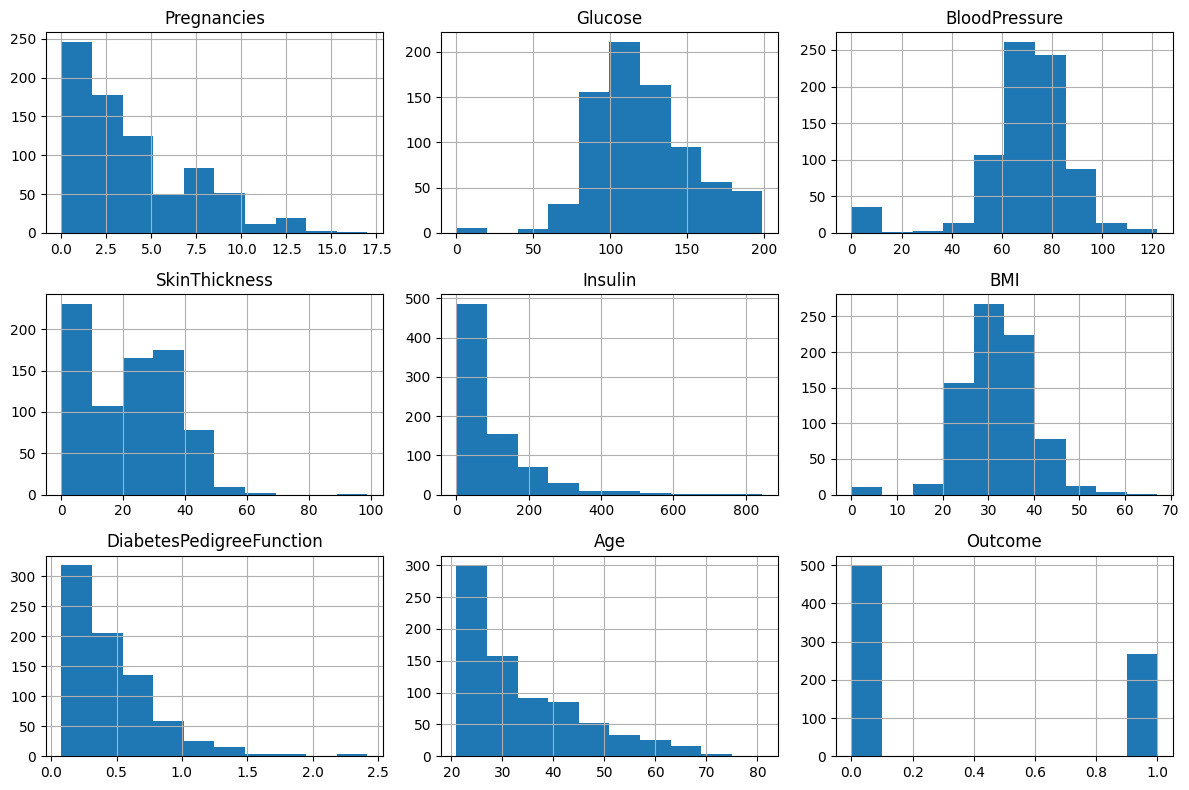

In [57]:
diabetes_df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()


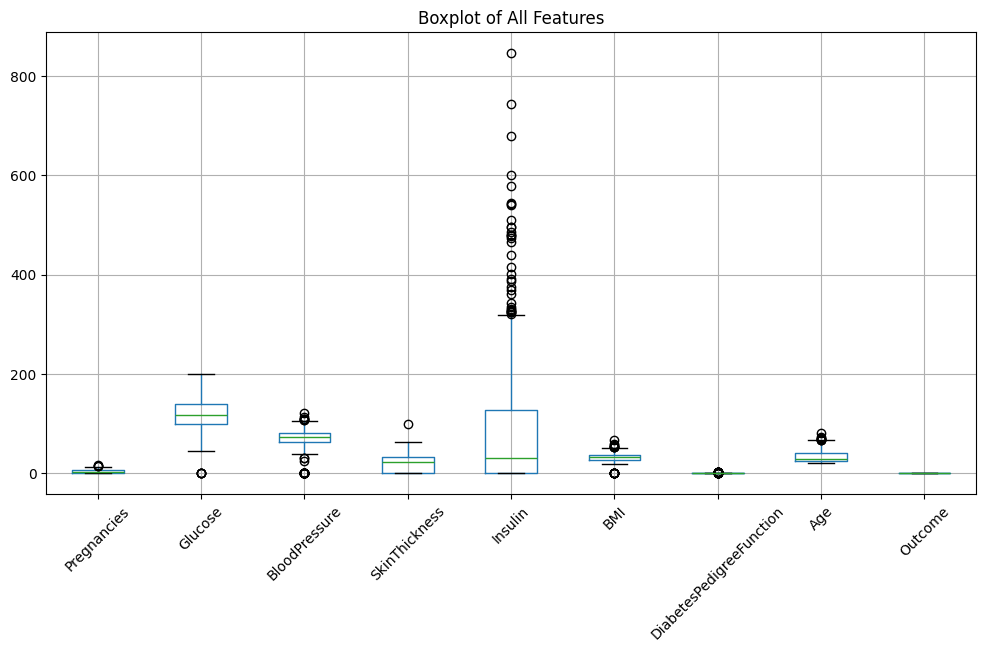

In [58]:
plt.figure(figsize=(12, 6))
diabetes_df.boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of All Features")
plt.show()


In [59]:
diabetes_df_totalnulls = diabetes_df.isnull().sum()
print(f"Total number of null values in each column: \n{diabetes_df_totalnulls}")

if diabetes_df_totalnulls.sum() == 0:
    print("\nDiabetes dataset has no missing values.")

Total number of null values in each column: 
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Diabetes dataset has no missing values.


In [60]:
cat_cols = diabetes_df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {cat_cols}")

cols_zero_count = (diabetes_df == 0).sum()
print(f"\nTotal number of 0 in each column of the dataset: \n{cols_zero_count}\n")

cols_missing = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in cols_missing:
    diabetes_df[col] = diabetes_df[col].replace(0, np.nan)

# Checking for Missing Values
missing_info = diabetes_df.isnull().sum() / len(diabetes_df) * 100
print(f"\nMissing Value Percentages: \n{missing_info}%\n")

# Handling Missing Values
for column in diabetes_df.columns:
    if missing_info[column] > 10:
        print(f"Column '{column}' has >10% missing. Filling with mean.")
        diabetes_df[column] = diabetes_df[column].fillna(diabetes_df[column].mean())
    elif missing_info[column] > 0:
        print(f"Column '{column}' has <=10% missing. Dropping rows.")
        diabetes_df = diabetes_df.dropna(subset=[column])

# Displaying the Results
print("\nData after processing:\n", diabetes_df.head())

# Verifying cleanup
verify_missing_data_handling = diabetes_df.isnull().sum()
print(f"\nRemaining missing values:\n{verify_missing_data_handling}")

Categorical columns: []

Total number of 0 in each column of the dataset: 
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64


Missing Value Percentages: 
Pregnancies                  0.000000
Glucose                      0.651042
BloodPressure                4.557292
SkinThickness               29.557292
Insulin                     48.697917
BMI                          1.432292
DiabetesPedigreeFunction     0.000000
Age                          0.000000
Outcome                      0.000000
dtype: float64%

Column 'Glucose' has <=10% missing. Dropping rows.
Column 'BloodPressure' has <=10% missing. Dropping rows.
Column 'SkinThickness' has >10% missing. Filling with mean.
Column 'Insulin' has >10% missing. Filling with mean.
Column 'BMI' 

In [61]:
# Declaring A Function to Split the Dataset in Training and Testing Data

def train_test_split_func(features, target, test_size=0.3, random_seed=42):
  """
  Splits a dataset into training and testing sets.

  Parameters :
  features : np.ndarray
    Feature matrix (rows = data samples, columns = freatures).
  target : np.ndarray
    Target array.
  test_size : float
    Proportion of data to allocate to the test set (0 < test_size < 1).
    Default: 0.3.
  random_seed : int
    Seed for random number generator to ensure reproducibility.
    Default: 42.

  Returns:
  X_train : np.ndarray
    Training features.
  X_test : np.ndarray
    Testing features.
  y_train : np.ndarray
    Training target values.
  y_test : np.ndarray
    Testing target values.
  """
  # Setting a random seed for reproducibility
  np.random.seed(random_seed)

  # Shuffling data indices
  indices = np.arange(features.shape[0])
  np.random.shuffle(indices)

  # Determineing number of test samples
  test_split_size = int(len(features) * test_size)

  # spliting indices into train and test indices
  test_indices = indices[:test_split_size]
  train_indices = indices[test_split_size:]

  # Creating training and testing sets
  X_train, X_test = features[train_indices], features[test_indices]
  y_train, y_test = target[train_indices], target[test_indices]
  return X_train, X_test, y_train, y_test


In [62]:
# Separating features and targets
features = diabetes_df.iloc[:, :-1].values
target = diabetes_df.iloc[:, -1].values

# Spitting the data into training and testing sets 70 - 30 %
X_train, X_test, y_train, y_test = train_test_split_func(features, target, test_size=0.3, random_seed=42)

# Outputs
# Features training set
print(f"Feature Training set: \n]n{X_train}\n")

# Featrues testing set
print(f"Feature Testing set: \n\n{X_test}")

Feature Training set: 
]n[[ 13.    152.     90.    ...  26.8     0.731  43.   ]
 [  3.     99.     62.    ...  21.8     0.279  26.   ]
 [  2.    105.     80.    ...  33.7     0.711  29.   ]
 ...
 [  5.    155.     84.    ...  38.7     0.619  34.   ]
 [  5.     88.     78.    ...  27.6     0.258  37.   ]
 [  3.    171.     72.    ...  33.3     0.199  24.   ]]

Feature Testing set: 

[[  1.    139.     46.    ...  28.7     0.654  22.   ]
 [  1.     88.     62.    ...  29.9     0.422  23.   ]
 [ 11.    111.     84.    ...  46.8     0.925  45.   ]
 ...
 [  6.    195.     70.    ...  30.9     0.328  31.   ]
 [  0.    139.     62.    ...  22.1     0.207  21.   ]
 [  4.    115.     72.    ...  28.9     0.376  46.   ]]


In [63]:

# Creating a function for calculating KNN prediction for a single query
def knn_predict_single_values(query, X_train, y_train, k=3):
  """
  This function predicts the class label for a single query(Actual Data X)
  using the K-nearest neighbors algorithm(KNN).

  Parameters:
  query : np.ndarray
    The query point for prediction .
  X_train : np.ndarray
  The training feature matrix.
  y_train : np.ndarray
  The training labels.
  k : int, optional
  The number of nearest neighbors to consider (default is 3).
  Returns:
  int
  The predicted class label for the query.
  """
  distances_calculation = [euclidean_distance(query, x) for x in X_train]
  sorted_indices = np.argsort(distances_calculation)
  indices_nearest_K = sorted_indices[:k]
  labels_nearest_K = y_train[indices_nearest_K]

  # Counting majority
  prediction = np.bincount(labels_nearest_K).argmax()
  return prediction


# Creating a function for calculating KNN prediction for for all samples
def knn_predict_whole(X_test, X_train, y_train, k=3):
  """
  This function predicts the class labels for all test samples using the
  K-nearest neighbors algorithm(KNN).

  Parameters:

  X_train : np.ndarray
    Training features.
  X_test : np.ndarray
    Testing features.
  y_train : np.ndarray
    Training target values.
  k : int
    Number of nearest neighbors to consider.

  Returns:
  np.ndarray
    Returns an array of predicted class labels for the test samples.
  """
  KNN_predictions = [knn_predict_single_values(x, X_train, y_train, k) for x in X_test]
  return np.array(KNN_predictions)

In [64]:
# Creating a function to calculate the eculidean distance between two points
def euclidean_distance(point1, point2):
  """
  This function calculate the Euclidean distance between two points in
  n-dimensional space.

  Parameters:
  point1 : np.ndarray
    The first point(co-ordinate) as a numpy array.
  point2 : np.ndarray
    The second point(co-ordinate) as a numpy array.

  Returns:
  float:
    returns the Euclidean distance between the two points.
  Raises:
    ValueError: raises an error if the points does not have same dimensionality.
  """

  # Checking whethe the points have the same dimenstionality
  if point1.shape != point2.shape:
    raise ValueError("To calculate the Euclidean distance, the point must be of same dimensionality.")

  # Calculating Euclidean distance (d(\mathbf{p,q})=\sqrt{\sum _{i=1}^{n}(q_{i}-p_{i})^{2}}\)
  ecu_distance = np.sqrt(np.sum((point1 - point2) ** 2))
  return ecu_distance

In [65]:
# Creating a function to compute accurary of predictions
def compute_accuracy(y_true, y_pred):
  """
  Compute the accuracy of predictions.
  Arguments:
  y_true : np.ndarray ; The true labels.
  y_pred : np.ndarray; The predicted labels.
  Returns:
  float : The accuracy as a percentage (0 to 100).
  """
  accurate_predictions = np.sum(y_true == y_pred)
  total_predictions = len(y_true)
  accuracy_per = (accurate_predictions / total_predictions) * 100
  return accuracy_per


===========Accuracy Data=============

Accuracy k=1: 74.65%
Accuracy k=3: 73.27%
Accuracy k=5: 70.97%
Accuracy k=7: 71.89%
Accuracy k=9: 75.12%
Accuracy k=11: 75.12%
Accuracy k=13: 74.65%
Accuracy k=15: 76.04%
Accuracy k=17: 76.96%
Accuracy k=19: 76.04%
Accuracy k=21: 77.88%
Accuracy k=23: 76.50%
Accuracy k=25: 75.12%
Accuracy k=27: 76.04%
Accuracy k=29: 76.04%
Accuracy k=31: 75.12%
Accuracy k=33: 76.50%
Accuracy k=35: 77.42%
Accuracy k=37: 77.42%
Accuracy k=39: 76.96%
Accuracy k=41: 75.58%
Accuracy k=43: 76.04%
Accuracy k=45: 74.65%
Accuracy k=47: 74.65%
Accuracy k=49: 74.65%


==================Visual Representation=================



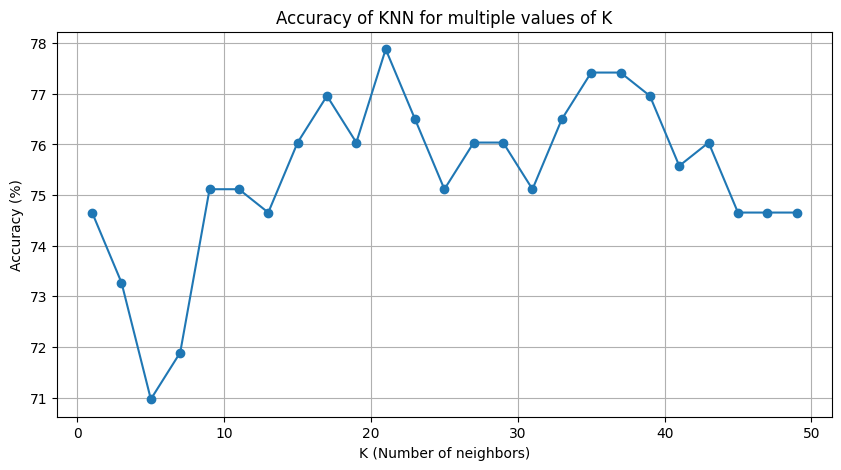

Completion of Accuracy Experiment with Different K Values.


In [66]:
# Creating a function for to test KNN on different values of k and plot the accuracies
def experiment_knn_k_values(X_train, y_train, X_test, y_test, k_values):
  """
  The function runs knn_predict_whole to compute predictions for
  different values of k and plot their accuracies.

  Parameters:
  X_train : np.ndarray
    Training features.
  y_train : np.ndarray
    Training target values.
  X_test : np.ndarray
    Testing features.
  y_test : np.ndarray
    Testing target values.
  k_values : list with int values
    list with int values to experiment with.

  Returns:
  dict :
    returns a dictionary with k = keys and their corresponding accuracies as values.
  """
  different_accuracies = {}

  print("\n===========Accuracy Data=============\n")
  for k in k_values:

    # Making predictions for K = current values.
    predictions = knn_predict_whole(X_test, X_train, y_train, k=k)
    # Computing the accuracy
    accuracy = compute_accuracy(y_test, predictions)
    different_accuracies[k] = accuracy
    print(f"Accuracy k={k}: {accuracy:.2f}%")

    # Plotting the accuracies
  print("\n\n==================Visual Representation=================\n")
  plt.figure(figsize=(10, 5))
  plt.plot(k_values, list(different_accuracies.values()), marker='o')
  plt.xlabel('K (Number of neighbors)')
  plt.ylabel('Accuracy (%)')
  plt.title('Accuracy of KNN for multiple values of K')
  plt.grid(True)
  plt.show()
  return different_accuracies

# Defining K range for experiment
k_values = range(1, 50, 2) # odd K values only

try:
  accuracies = experiment_knn_k_values(X_train, y_train, X_test, y_test, k_values)
  print("Completion of Accuracy Experiment with Different K Values.")
except Exception as e:
  print(f"An unexpected error occurred during the experiment: {e}")

The label prediction accuracy increase as the value of K increases from 1. This represents that as the value of K increases the program is less sensitive to noise. i.e. The classification accuracy at K = 3 is all time lowest 70.97%. The highest accurarcy 77.88% occurs at K = 21 and beyond that point the accurary is obsereved to gradually drop as a result of underfitting. Hence based on the observation K = 21 is the optimal value.

## **Problem - 2 - Experimentation:**
**1. Repeat the Classification Task:**
- Scale the Feature matrix X.
- Use the scaled data for training and testing the kNN Classifier.
- Record the results.

**2. Comparative Analysis: Compare the Results -**
- Compare the accuracy and performance of the kNN model on the original dataset from problem 1 versus the scaled dataset.
- Discuss:
  - How scaling impacted the KNN performance
  - The reason for any observed changes.

In [67]:
# Creating a function that will Scale (Normalize) the Feature Matrux X
def scale_normalize(X):
  """
  This function will scale the feature matrix X.

  Parameters:
  X : np.ndarray
    Acutal Data Feature

  Returns:
  np.ndarray
    Returns the scaled feature matrix.

  """
  normalize_scale = (X - X.min(axis = 0)) / (X.max(axis = 0) - X.min(axis = 0))
  return normalize_scale

# Calling scale_feature
features_scaled = scale_normalize(features)

# Verifying output
print(f"Caluclated Scaled Features: \n\n{features_scaled}")

Caluclated Scaled Features: 

[[0.35294118 0.67096774 0.48979592 ... 0.31492843 0.23441503 0.48333333]
 [0.05882353 0.26451613 0.42857143 ... 0.17177914 0.11656704 0.16666667]
 [0.47058824 0.89677419 0.40816327 ... 0.10429448 0.25362938 0.18333333]
 ...
 [0.29411765 0.49677419 0.48979592 ... 0.16359918 0.07130658 0.15      ]
 [0.05882353 0.52903226 0.36734694 ... 0.24335378 0.11571307 0.43333333]
 [0.05882353 0.31612903 0.46938776 ... 0.24948875 0.10119556 0.03333333]]


In [68]:
X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split_func(
    features_scaled, target, test_size=0.3, random_seed=42
)

# Verifying
print("Shape of X_train_scaled:", X_train_scaled.shape)
print("Shape of X_test_scaled:", X_test_scaled.shape)
print("Shape of y_train_scaled:", y_train_scaled.shape)
print("Shape of y_test_scaled:", y_test_scaled.shape)

Shape of X_train_scaled: (507, 8)
Shape of X_test_scaled: (217, 8)
Shape of y_train_scaled: (507,)
Shape of y_test_scaled: (217,)



===========Accuracy Data=============

Accuracy k=1: 72.81%
Accuracy k=3: 74.65%
Accuracy k=5: 74.65%
Accuracy k=7: 77.42%
Accuracy k=9: 76.96%
Accuracy k=11: 77.42%
Accuracy k=13: 78.34%
Accuracy k=15: 77.88%
Accuracy k=17: 78.80%
Accuracy k=19: 76.50%
Accuracy k=21: 77.42%
Accuracy k=23: 78.80%
Accuracy k=25: 78.34%
Accuracy k=27: 77.88%
Accuracy k=29: 78.80%
Accuracy k=31: 77.88%
Accuracy k=33: 78.34%
Accuracy k=35: 76.96%
Accuracy k=37: 77.88%
Accuracy k=39: 77.88%
Accuracy k=41: 77.88%
Accuracy k=43: 76.50%
Accuracy k=45: 75.58%
Accuracy k=47: 76.96%
Accuracy k=49: 76.04%


==================Visual Representation=================



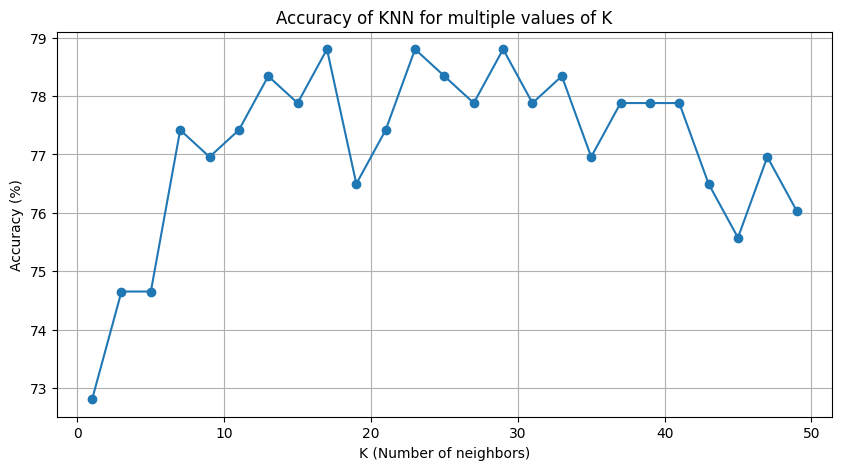

Completion of Accuracy Experiment with Different K Values.


In [69]:
# Defining K range for experiment
k_values = range(1, 50, 2) # odd K values only

try:
  accuracies = experiment_knn_k_values(X_train_scaled, y_train, X_test_scaled, y_test, k_values)
  print("Completion of Accuracy Experiment with Different K Values.")
except Exception as e:
  print(f"An unexpected error occurred during the experiment: {e}")


Scaling helps reduce time comsumption and increases accuracy for prediction. Since KNN is a distance-based algorithm by scaling, all features contribute proportionally proventing any single feature from heaveily influencing the results.

## **Problem - 3 - Experimentation with k:**
**1. Vary the number of neighbors - k:**
- Run the KNN model on both the original and scaled datasets for a range of k= 1, 2, 3, . . . 15
- For each k, record: Accuracy, Time taken.

**2. Visualize the Results:**
- Plot: k vs. Accuracy, k vs. Time Taken.

**3. Analyze and Discuss:**
- Discuss how choice of k affects accuracy/cost. Identify optimal k.

In [70]:
# Importing time module
import time

# Creating a function to test KNN with different k values and measure time
def experiment_knn_with_time(X_train, y_train, X_test, y_test, k_values):
  """
  The function runs knn_predict_whole to compute predictions for
  different values of k and records both accuracy and prediction time.

  Parameters:
  X_train : np.ndarray
    Training features.
  y_train : np.ndarray
    Training target values.
  X_test : np.ndarray
    Testing features.
  y_test : np.ndarray
    Testing target values.
  k_values : list with int values
    List with int values to experiment with.

  Returns:
  dict :
    Returns a dictionary with k as keys and dict of accuracy and time as values.
    Format: {k: {"accuracy": float, "time": float}}
  """
  results = {}

  print("\n" + "="*70)
  print("EXPERIMENT: K-NN with Accuracy and Time Measurement")
  print("="*70 + "\n")

  for k in k_values:

    # Starting the timer
    start_time = time.time()

    # Making predictions for K = current values.
    predictions = knn_predict_whole(X_test, X_train, y_train, k=k)

    # Ending the timer
    end_time = time.time()

    # Calculating elapsed time
    elapsed_time = end_time - start_time

    # Computing the accuracy
    accuracy = compute_accuracy(y_test, predictions)

    results[k] = {
            "accuracy": accuracy,
            "time": elapsed_time
        }

    print(f"K={k:2d} | Accuracy={accuracy:6.2f}% | Time={elapsed_time:.4f}s")

  print("\n" + "="*70)
  return results

In [71]:
# Defining K range for experiment
k_values = range(1, 16) # range 1-15

try:
  original_results = experiment_knn_with_time(
      X_train, y_train, X_test, y_test, k_values
  )

  scaled_results = experiment_knn_with_time(
      X_train_scaled, y_train, X_test_scaled, y_test, k_values
  )

  print("Completion of Accuracy Experiment with Different K Values.")
except Exception as e:
  print(f"An unexpected error occurred during the experiment: {e}")




EXPERIMENT: K-NN with Accuracy and Time Measurement

K= 1 | Accuracy= 74.65% | Time=0.5738s
K= 2 | Accuracy= 71.89% | Time=0.5363s
K= 3 | Accuracy= 73.27% | Time=0.7827s
K= 4 | Accuracy= 75.12% | Time=0.7508s
K= 5 | Accuracy= 70.97% | Time=0.5364s
K= 6 | Accuracy= 70.97% | Time=0.5652s
K= 7 | Accuracy= 71.89% | Time=0.5407s
K= 8 | Accuracy= 73.73% | Time=0.5456s
K= 9 | Accuracy= 75.12% | Time=0.5428s
K=10 | Accuracy= 74.65% | Time=0.5558s
K=11 | Accuracy= 75.12% | Time=0.5312s
K=12 | Accuracy= 76.04% | Time=0.5558s
K=13 | Accuracy= 74.65% | Time=0.5384s
K=14 | Accuracy= 76.04% | Time=0.9262s
K=15 | Accuracy= 76.04% | Time=0.9722s


EXPERIMENT: K-NN with Accuracy and Time Measurement

K= 1 | Accuracy= 72.81% | Time=0.6461s
K= 2 | Accuracy= 72.81% | Time=0.5417s
K= 3 | Accuracy= 74.65% | Time=0.5511s
K= 4 | Accuracy= 76.50% | Time=0.5349s
K= 5 | Accuracy= 74.65% | Time=0.5640s
K= 6 | Accuracy= 76.50% | Time=0.5237s
K= 7 | Accuracy= 77.42% | Time=0.5691s
K= 8 | Accuracy= 78.34% | Time=0.

In [72]:

def plot_knn_accuracy(original_results, scaled_results, title="KNN Accuracy vs K"):
    """
    This function plots the accuracy of KNN for different values of K.

    Parameters:
    results : dict
        A dictionary containing the accuracy results for different values of K.

    Returns:
    None
    """
    k_values = list(original_results.keys())
    original_accuracies = [original_results[k]["accuracy"] for k in k_values]
    scaled_accuracies = [scaled_results[k]["accuracy"] for k in k_values]

    plt.figure(figsize=(10, 5))
    plt.plot(k_values, original_accuracies, marker='o', label='Original Data')
    plt.plot(k_values, scaled_accuracies, marker='s', label='Scaled Data')
    plt.xlabel("K (Number of neighbors)")
    plt.ylabel("Accuracy (%)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_knn_time(original_results, scaled_results, title="KNN Prediction Time vs K"):
    """
    This function plots the computation time of KNN for different values of K.

    Parameters:
    results : dict
        A dictionary containing the computation time results for different
        values of K.

    Returns:
    None
    """
    k_values = list(original_results.keys())
    original_times = [original_results[k]["time"] for k in k_values]
    scaled_times = [scaled_results[k]["time"] for k in k_values]

    plt.figure(figsize=(10, 5))
    plt.plot(k_values, original_times, marker='o', label='Original Data')
    plt.plot(k_values, scaled_times, marker='s', label='Scaled Data')
    plt.xlabel("K (Number of neighbors)")
    plt.ylabel("Time (seconds)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


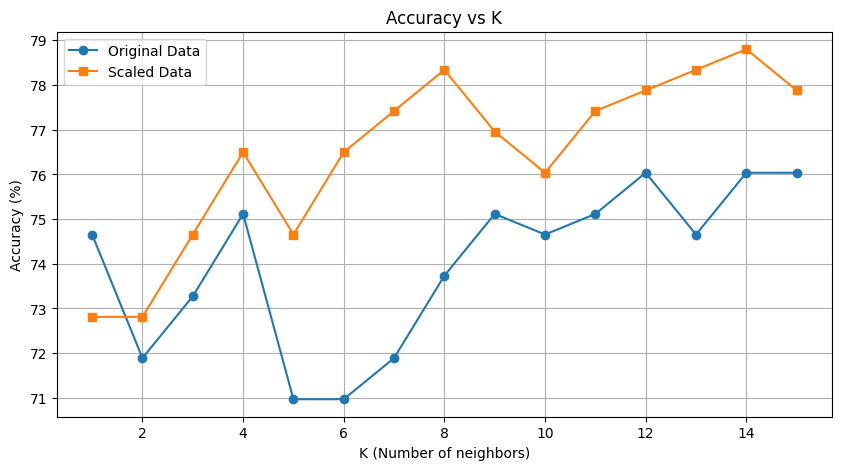

In [73]:
# Plotting with K values against Accuracy

plot_knn_accuracy(original_results, scaled_results, "Accuracy vs K")



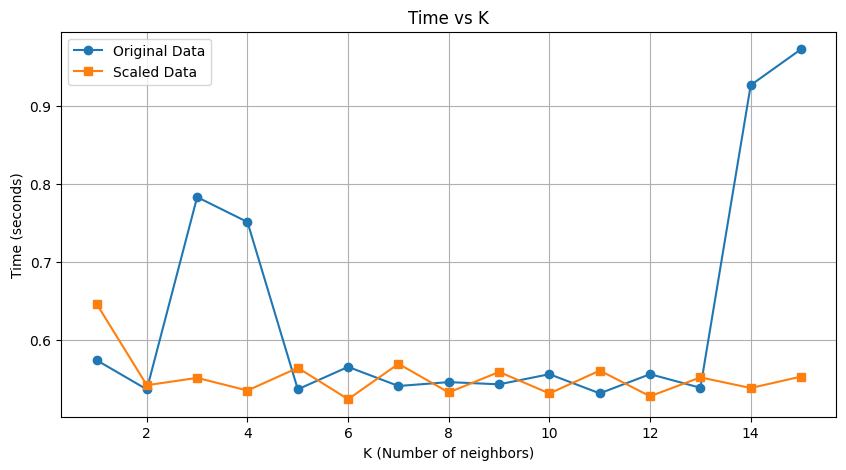

In [74]:
# Plotting with K values against time

plot_knn_time(original_results, scaled_results, "Time vs K")

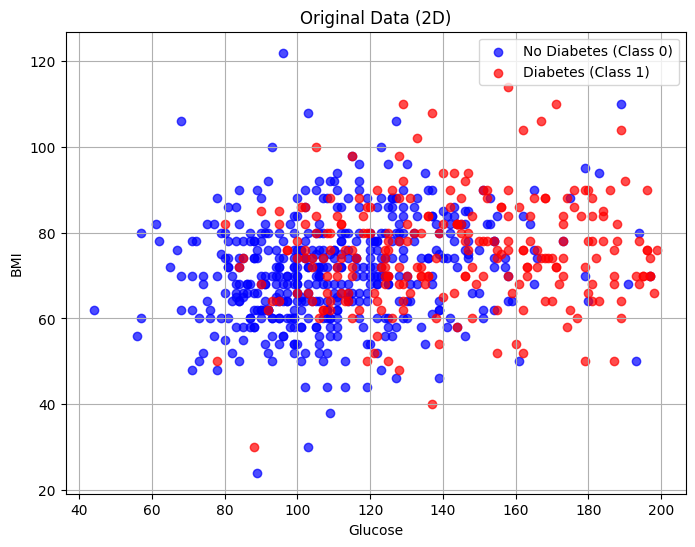

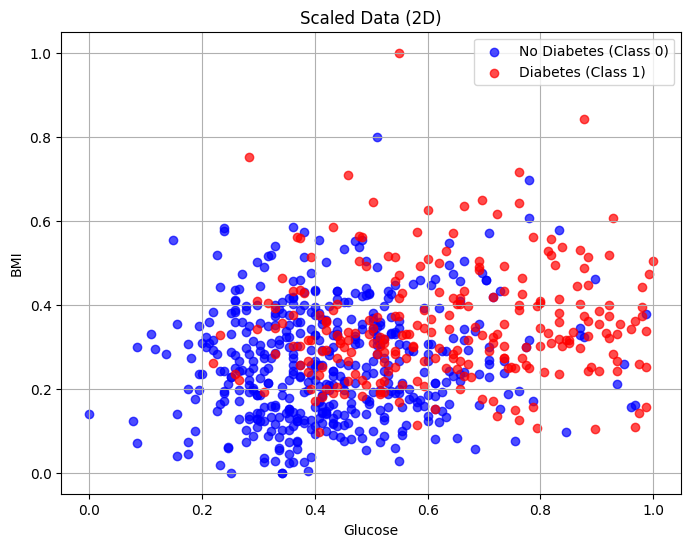

In [75]:
def plot_2d_scatter(X, y, title="2D Scatter Plot"):
    """
    Plots a 2D scatter of the data colored by class labels.
    """
    plt.figure(figsize=(8, 6))

    plt.scatter(X[y == 0, 0], X[y == 0, 1], label="No Diabetes (Class 0)", alpha=0.7, color='blue')
    plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Diabetes (Class 1)", alpha=0.7, color='red')
    plt.xlabel("Glucose")
    plt.ylabel("BMI")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

X_vis_orig = features[:, [1, 2]]
X_vis_scaled = features_scaled[:, [1, 5]]

y_vis = target

# Original dataset
plot_2d_scatter(X_vis_orig, y_vis, title="Original Data (2D)")

# Scaled dataset
plot_2d_scatter(X_vis_scaled, y_vis, title="Scaled Data (2D)")

### 3. Analysis
- **Effect of k on Accuracy**: In a general term, Accuracy is deeply dependent in K value. Low K values (eg, k = 1) captures noise and can possibly be overfit whereas High K values smooth out the decision boundary causing underfitting. From the above result, the optimal K is K=14 since the accuracy is the highest amoung the testing datas.

- **Computational Cost**: KNN prediction time remains nearly constant across different k values because of the main cost—computing distances to all training points (O(N × D)) which is independent of k. Furthermore, Selecting the top-k neighbors and voting the maximum prediction afterwards adds negligible overhead. Thus, runtime shows little variation with k.

## Problem - 4 - Additional Questions
**1. Discuss the challenges of using KNN for large datasets and high-dimensional data.**
- **Large Datasets**:
  - KNN is a lazy learner so it stores all data rather than learning a model.
  - KNN predicts labels through iteration of the whole dataset for every single query point.
  - Logically: For $N$ training samples, prediction is $O(N)$, which is **extremely** slow for a large set of records.
- **High Dimensions**:
  - KNN is also affected by the "Curse of Dimensionality".
  - In high dimensions, space volume increases exponentially and data becomes sparse.
  - In high Dim, the distance between the datas are extremely "far", so this makes the Euclidean distance a very poor metric for similarity.

**2. Suggest strategies to improve efficiency.**
- **Approximate Nearest Neighbors (ANN)**:
  - Data structures like KD-Trees or Ball Trees can be used to discard large chunks of data points that are definitely far away, reducing time complexity search from $O(N)$ to $O(\log N)$.
- **Dimensionality Reduction**:
  - By applying PCA (Principal Component Analysis) or feature selection.
  - This helps reduce the number of dimensions ($D$) before running KNN and makes distance calculations faster and reliable.